# Feature Attribution for Linear Family UHPC Predictions

In this notebook, I have try to explain the feature-attribution workflow for the S1 Linear Family model. The goal is not to train a new model from scratch, but to interpret the fitted publication-held-out Elastic Net pipeline.

The main presentation question is:

**Which original UHPC features and engineering feature groups are most responsible for the model's predictions on unseen publications?**

## 1. Attribution Strategy

The attribution workflow builds on the earlier modeling pipeline:

- the shared semantic 50 percent UHPC feature setup,
- publication-held-out evaluation, where test publications are unseen during training and validation,
- the saved train-only Elastic Net pipeline used for uncertainty and attribution,
- SHAP and held-out permutation importance as complementary explanation checks.

For presentation consistency, I have used the grouped SHAP table below as: **sum the individual feature mean-absolute SHAP values inside each physical group**.

## 2. Why Feature Attribution?

Prediction metrics tell us whether the model is accurate, but they do not explain *why* the model predicts a high or low 28-day compressive strength value. Feature attribution helps answer three practical questions:

1. **Group-level dominance:** Are curing conditions, binders/SCMs, fibres, fillers/aggregates, water, or chemical admixtures driving predictions most strongly?
2. **Individual feature dominance:** Within those groups, which original input features matter most?
3. **Plausibility:** Do the strongest features make engineering sense for UHPC compressive strength?

We compare SHAP attribution with held-out permutation importance as a reliability check, not as a new model-selection step.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import HTML, Image, display

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', '{:.3f}'.format)

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

TABLE_DIR = ROOT / 'reports' / 'tables' / 'week10'
FIGURE_DIR = ROOT / 'reports' / 'figures' / 'week10'
METRIC_DIR = ROOT / 'results' / 'metrics' / 'week10'
PREDICTION_DIR = ROOT / 'results' / 'predictions' / 'week10'

GROUP_LABELS = {
    'binders_and_scms': 'Binders and SCMs',
    'fillers_and_aggregates': 'Fillers and Aggregates',
    'fibers': 'Fibres',
    'water': 'Water',
    'chemical_admixtures': 'Chemical Admixtures',
    'curing': 'Curing',
}

print(f'Project root: {ROOT}')
print(f'Tables exist: {TABLE_DIR.exists()}')
print(f'Figures exist: {FIGURE_DIR.exists()}')

Project root: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Data-to-Design-ML/S1_Linear
Tables exist: True
Figures exist: True


In [2]:
readiness = pd.read_csv(TABLE_DIR / 'week10_readiness_audit.csv')
feature_group_mapping = pd.read_csv(TABLE_DIR / 'week10_feature_group_mapping.csv')
transformed_mapping = pd.read_csv(TABLE_DIR / 'week10_transformed_to_original_mapping.csv')
shap_original = pd.read_csv(TABLE_DIR / 'week10_shap_original_feature_importance.csv')
shap_group = pd.read_csv(TABLE_DIR / 'week10_shap_group_importance.csv')
shap_additivity = pd.read_csv(TABLE_DIR / 'week10_shap_prediction_additivity_audit.csv')
feature_permutation = pd.read_csv(METRIC_DIR / 'week10_feature_permutation_importance.csv')
group_permutation = pd.read_csv(METRIC_DIR / 'week10_group_permutation_importance.csv')
agreement = pd.read_csv(TABLE_DIR / 'week10_shap_permutation_agreement.csv')

print('Loaded feature-attribution result tables:')
for name, df in {
    'readiness': readiness,
    'feature_group_mapping': feature_group_mapping,
    'transformed_mapping': transformed_mapping,
    'shap_original': shap_original,
    'shap_group': shap_group,
    'feature_permutation': feature_permutation,
    'group_permutation': group_permutation,
    'agreement': agreement,
}.items():
    print(f'- {name}: {df.shape[0]} rows x {df.shape[1]} columns')

Loaded feature-attribution result tables:
- readiness: 10 rows x 4 columns
- feature_group_mapping: 33 rows x 3 columns
- transformed_mapping: 58 rows x 6 columns
- shap_original: 33 rows x 9 columns
- shap_group: 6 rows x 8 columns
- feature_permutation: 33 rows x 13 columns
- group_permutation: 6 rows x 13 columns
- agreement: 2 rows x 5 columns


## 3. Readiness and Leakage Checks

Before interpreting feature attribution, we first confirm that the setup is appropriate:

- The model is the configured train-only **Elastic Net** model.
- The test set rows, targets, and publication lineage are aligned.
- The target variable is not included in the predictors.
- Publication lineage columns are not included in the predictors.
- The number of transformed features matches the number of fitted linear coefficients.
- Permutation importance reuses the fitted model and does **not** retrain models.

This matters because attribution is only meaningful if the fitted pipeline and held-out test data are aligned correctly.

In [3]:
display(readiness)

,check,value,status,detail
0,week09_readiness_audit_passed,0,pass,Week 10 reuses the frozen Week 9 input audit.
1,model_name,Elastic Net,pass,Week 10 is configured to explain the Week 9 El...
2,test_row_alignment,311/311/311,pass,"X_test, y_test, and test lineage rows must align."
3,target_not_in_predictors,cs_28d,pass,Target values are only used for evaluation.
4,lineage_columns_not_in_predictors,0,pass,NaN
5,transformed_feature_count_matches_coefficients,58/58,pass,Each transformed feature needs exactly one lin...
6,shap_package_available,True,pass,SHAP is installed and shap.LinearExplainer was...
7,shap_method_used,shap.LinearExplainer,pass,Method used for transformed-space SHAP values.
8,shap_additivity,2.842170943040401e-14,pass,Tolerance: 1e-06
9,permutation_refits_model,False,pass,Week 10 permutation importance reuses the fitt...


The readiness audit passes the critical checks. The `shap` package is installed in the local environment, so the runner uses `shap.LinearExplainer` for the fitted Elastic Net pipeline.

For a linear model, SHAP attribution decomposes each prediction around a background expectation using the transformed model inputs and fitted linear coefficients. This is why the additivity check below is important: the sum of feature attributions plus the expected value should reconstruct the model prediction.

In [4]:
display(shap_additivity)

,row_position,prediction,shap_base_value,shap_sum,reconstructed_prediction,absolute_additivity_error
0,0,138.980,147.212,-8.232,138.980,0.000
1,1,139.792,147.212,-7.420,139.792,0.000
2,2,139.233,147.212,-7.979,139.233,0.000
3,3,145.405,147.212,-1.807,145.405,0.000
4,4,133.215,147.212,-13.997,133.215,0.000
...,...,...,...,...,...,...
306,306,169.827,147.212,22.615,169.827,0.000
307,307,173.128,147.212,25.916,173.128,0.000
308,308,176.429,147.212,29.217,176.429,0.000
309,309,179.731,147.212,32.518,179.731,0.000


The additivity error is effectively zero, so the attribution values reconstruct the model predictions correctly. This gives confidence that the attribution pipeline is technically consistent.

## 4. Feature Mapping Strategy

The model is trained after preprocessing. That means the model sees transformed columns, not only the raw original columns. Examples include:

- scaled numeric features,
- one-hot encoded categorical levels,
- target-encoded high-cardinality categorical columns.

For interpretation, transformed columns are mapped back to their original feature names. Then original features are assigned to engineering groups:

- `binders_and_scms`
- `fillers_and_aggregates`
- `fibers`
- `water`
- `chemical_admixtures`
- `curing`

This lets us report both individual feature importance and group-level importance.

In [5]:
print('Transformed feature mapping status:')
display(transformed_mapping['mapping_status'].value_counts().rename_axis('mapping_status').reset_index(name='count'))

print('Original features per configured group:')
feature_group_summary = (
    feature_group_mapping
    .assign(feature_group_label=lambda df: df['feature_group'].map(GROUP_LABELS).fillna(df['feature_group']))
    .groupby(['feature_group_label', 'feature_group'])['original_feature']
    .agg(['count', lambda values: ', '.join(values)])
    .rename(columns={'<lambda_0>': 'features'})
    .reset_index()
    .sort_values('feature_group_label')
)
display(feature_group_summary)

Transformed feature mapping status:


,mapping_status,count
0,mapped,58


Original features per configured group:


,feature_group_label,feature_group,count,features
0,Binders and SCMs,binders_and_scms,17,"cement, cement_type, silica_fume, fly_ash, fly..."
1,Chemical Admixtures,chemical_admixtures,2,"sp_type, sp_amount"
2,Curing,curing,2,"curing_method, curing_temp"
3,Fibres,fibers,6,"fiber1_type, fiber1_amount, fiber1_length, fib..."
4,Fillers and Aggregates,fillers_and_aggregates,5,"filler, filler_type, sand, sand_type, sand_max..."
5,Water,water,1,water


All transformed model columns are mapped back to original features. This is important because reporting transformed dummy columns directly would be harder to explain in a presentation. The grouped view is more useful for answering the engineering question: *which material or process category is most influential?*

## 5. Original-Feature Attribution Results

The table below ranks original features by mean absolute attribution on the publication-held-out test set. Higher values mean the feature contributed more strongly to the model's predictions, regardless of whether the contribution increased or decreased predicted strength.

In [6]:
cols = [
    'shap_rank',
    'original_feature',
    'feature_group',
    'mean_abs_shap',
    'mean_signed_shap',
    'mean_abs_share',
    'max_abs_shap',
]
shap_original_display = shap_original[cols].copy()
shap_original_display['feature_group'] = shap_original_display['feature_group'].map(GROUP_LABELS).fillna(shap_original_display['feature_group'])
display(shap_original_display.head(15))

,shap_rank,original_feature,feature_group,mean_abs_shap,mean_signed_shap,mean_abs_share,max_abs_shap
0,1,curing_temp,Curing,12.273,6.331,0.195,39.719
1,2,sand_type,Fillers and Aggregates,7.620,4.624,0.121,11.780
2,3,fiber1_amount,Fibres,6.571,1.274,0.104,31.447
3,4,fly_ash_type,Binders and SCMs,5.186,-2.573,0.082,17.180
4,5,cement_type,Binders and SCMs,3.430,-1.801,0.054,13.954
5,6,silica_fume,Binders and SCMs,3.375,1.898,0.053,11.285
6,7,fly_ash,Binders and SCMs,3.148,2.373,0.050,16.505
7,8,fiber1_type,Fibres,2.913,0.590,0.046,5.188
8,9,water,Water,2.784,2.263,0.044,9.204
9,10,sp_type,Chemical Admixtures,2.188,0.753,0.035,8.585


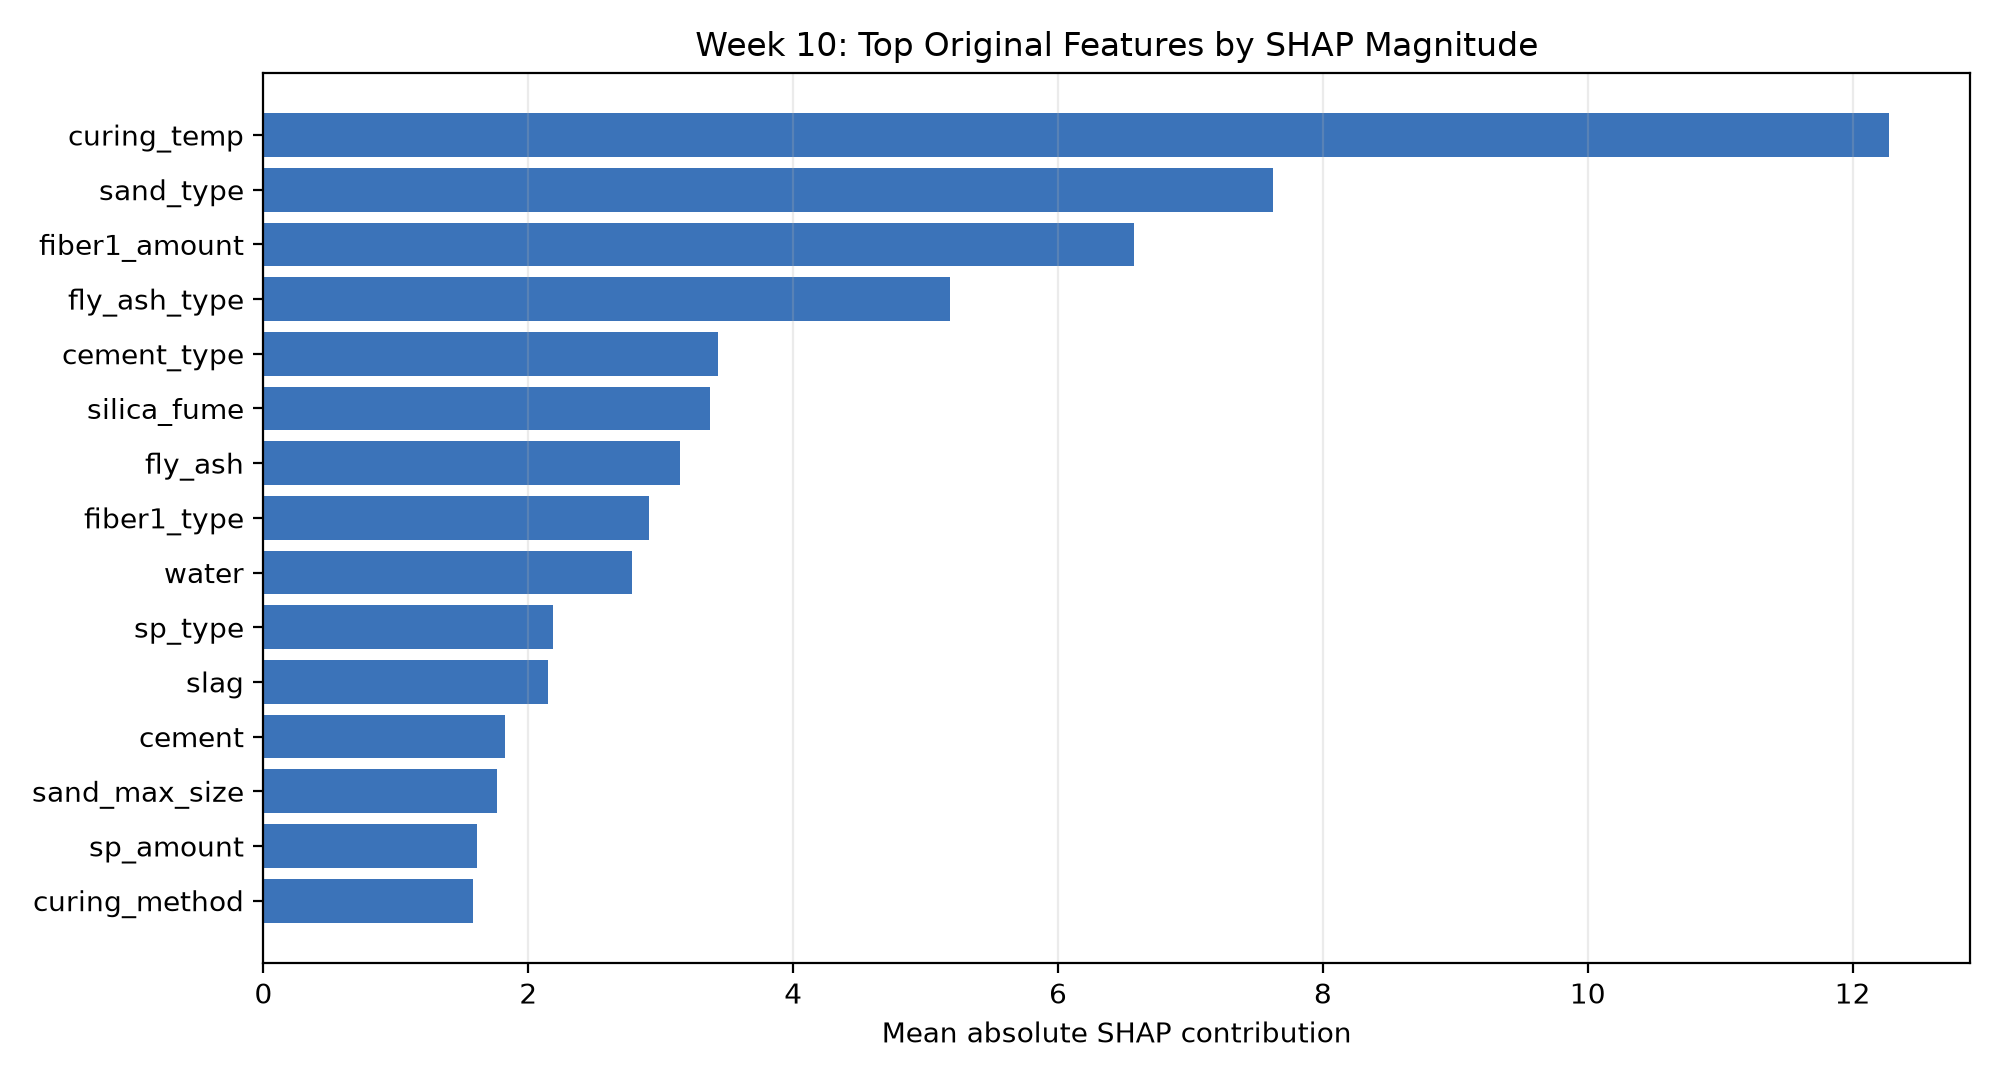

In [7]:
display(Image(filename=str(FIGURE_DIR / 'week10_top_original_shap.png')))

### Interpretation

The strongest individual feature is **curing temperature**. This is plausible for UHPC because curing temperature can strongly influence hydration, pozzolanic reaction, and early microstructure development.

The next important features include **sand type**, **fibre amount**, **fly ash type**, **cement type**, and **silica fume**. These are also plausible:

- Fibre amount can change post-cracking behavior and may correlate with specialized UHPC mix designs.
- Silica fume and SCM variables are central to dense particle packing and matrix strength.
- Sand type and aggregate/filler characteristics may capture differences in particle packing, grading, and dataset-specific formulation choices.
- Cement type and fly ash type may represent chemistry differences that the linear model can use after encoding.

The signed attribution column should be interpreted carefully. A positive mean signed value means the feature tends to increase predictions on average in this test set; a negative value means it tends to decrease predictions on average. This does not prove causality because the model is observational and features can be correlated.

## 6. Group-Level Attribution Results

Group-level attribution answers the same question at a higher level: which engineering categories dominate model predictions?

For presentation comparability, the main grouped SHAP column below is **the sum of individual feature mean-absolute SHAP values inside each group**. It is slightly different from taking the absolute value after first summing signed group contributions, because positive and negative feature effects can cancel inside a large group.

In [8]:
group_attribution_report = (
    shap_group[['feature_group', 'sum_mean_abs_original_feature_shap']]
    .merge(
        group_permutation[['feature_group', 'mean_rmse_delta', 'std_rmse_delta', 'permutation_rank']],
        on='feature_group',
        how='left',
        validate='one_to_one',
    )
    .rename(columns={
        'sum_mean_abs_original_feature_shap': 'shap_mean_teammate_style',
        'mean_rmse_delta': 'permutation_mean_rmse',
        'std_rmse_delta': 'permutation_std',
    })
    .sort_values('shap_mean_teammate_style', ascending=False)
    .reset_index(drop=True)
)
group_attribution_report['shap_sum_rank'] = range(1, len(group_attribution_report) + 1)
group_attribution_report['feature_group_label'] = (
    group_attribution_report['feature_group'].map(GROUP_LABELS).fillna(group_attribution_report['feature_group'])
)

group_attribution_display = group_attribution_report[[
    'shap_sum_rank',
    'feature_group_label',
    'shap_mean_teammate_style',
    'permutation_mean_rmse',
    'permutation_std',
    'permutation_rank',
]].rename(columns={
    'shap_sum_rank': 'SHAP Rank',
    'feature_group_label': 'Feature Group',
    'shap_mean_teammate_style': 'SHAP Mean',
    'permutation_mean_rmse': 'Permutation Mean RMSE',
    'permutation_std': 'Permutation Std',
    'permutation_rank': 'Permutation Rank',
})

display(group_attribution_display)

,SHAP Rank,Feature Group,SHAP Mean,Permutation Mean RMSE,Permutation Std,Permutation Rank
0,1,Binders and SCMs,21.495,0.862,0.430,4
1,2,Curing,13.852,8.519,0.849,1
2,3,Fillers and Aggregates,11.078,2.250,0.291,3
3,4,Fibres,10.085,3.838,0.507,2
4,5,Chemical Admixtures,3.801,0.249,0.179,6
5,6,Water,2.784,0.535,0.120,5


In [9]:
plot_df = group_attribution_report.sort_values('shap_mean_teammate_style', ascending=False).copy()
max_value = plot_df['shap_mean_teammate_style'].max()
rows = []
for row in plot_df.itertuples(index=False):
    width = 100 * row.shap_mean_teammate_style / max_value if max_value else 0
    rows.append(
        '<tr>'
        f'<td style="padding:4px 10px 4px 0; white-space:nowrap;">{row.feature_group_label}</td>'
        '<td style="width:330px; padding:4px 0;">'
        f'<div style="background:#4C78A8; height:16px; width:{width:.1f}%;"></div>'
        '</td>'
        f'<td style="padding-left:10px; text-align:right;">{row.shap_mean_teammate_style:.2f}</td>'
        '</tr>'
    )

html = (
    '<div style="max-width:720px;">'
    '<div style="font-weight:600; margin-bottom:6px;">Grouped SHAP using teammate-style feature-level sum</div>'
    '<table style="border-collapse:collapse; font-size:14px;">'
    + ''.join(rows)
    + '</table></div>'
)
display(HTML(html))

Binders and SCMs,,21.50
Curing,,13.85
Fillers and Aggregates,,11.08
Fibres,,10.09
Chemical Admixtures,,3.80
Water,,2.78


### Interpretation

Using the grouped SHAP , **Binders and SCMs** have the largest total attribution because this group contains many cementitious and SCM variables. **Curing** is second by total grouped SHAP and is still the strongest individual feature group by predictive damage.

This is the key presentation point: SHAP and permutation answer different questions.

1. **SHAP Mean** shows how much prediction contribution is distributed across the features in a group.
2. **Permutation Mean RMSE** shows how much test error increases when that group is shuffled.

For our Elastic Net model, **curing temperature** is the strongest individual feature, and **curing** is the group that damages held-out prediction accuracy the most when permuted.

## 7. Held-Out Permutation Importance

SHAP-style attribution decomposes predictions. Permutation importance asks a slightly different reliability question:

**How much worse does test-set RMSE become when one feature, or one feature group, is randomly shuffled while the trained model is kept fixed?**

This is useful because it tests whether the model actually depends on that feature for held-out predictive performance. The implementation uses 30 repeats and does not retrain the model during permutation.

In [10]:
perm_cols = [
    'permutation_rank',
    'original_feature',
    'feature_group',
    'baseline_rmse',
    'mean_permuted_rmse',
    'mean_rmse_delta',
    'std_rmse_delta',
    'mean_rmse_delta_percentage',
]
feature_permutation_display = feature_permutation[perm_cols].copy()
feature_permutation_display['feature_group'] = feature_permutation_display['feature_group'].map(GROUP_LABELS).fillna(feature_permutation_display['feature_group'])
display(feature_permutation_display.head(15))

,permutation_rank,original_feature,feature_group,baseline_rmse,mean_permuted_rmse,mean_rmse_delta,std_rmse_delta,mean_rmse_delta_percentage
0,1,curing_temp,Curing,28.488,37.023,8.535,0.827,29.960
1,2,fiber1_amount,Fibres,28.488,30.818,2.331,0.419,8.181
2,3,sand_type,Fillers and Aggregates,28.488,29.827,1.339,0.384,4.700
3,4,silica_fume,Binders and SCMs,28.488,29.500,1.012,0.185,3.553
4,5,sp_type,Chemical Admixtures,28.488,29.351,0.863,0.147,3.030
5,6,fiber1_type,Fibres,28.488,29.062,0.574,0.139,2.013
6,7,sand_max_size,Fillers and Aggregates,28.488,29.045,0.557,0.102,1.955
7,8,water,Water,28.488,29.028,0.540,0.131,1.895
8,9,fly_ash_type,Binders and SCMs,28.488,29.023,0.535,0.289,1.877
9,10,fly_ash,Binders and SCMs,28.488,28.995,0.507,0.131,1.780


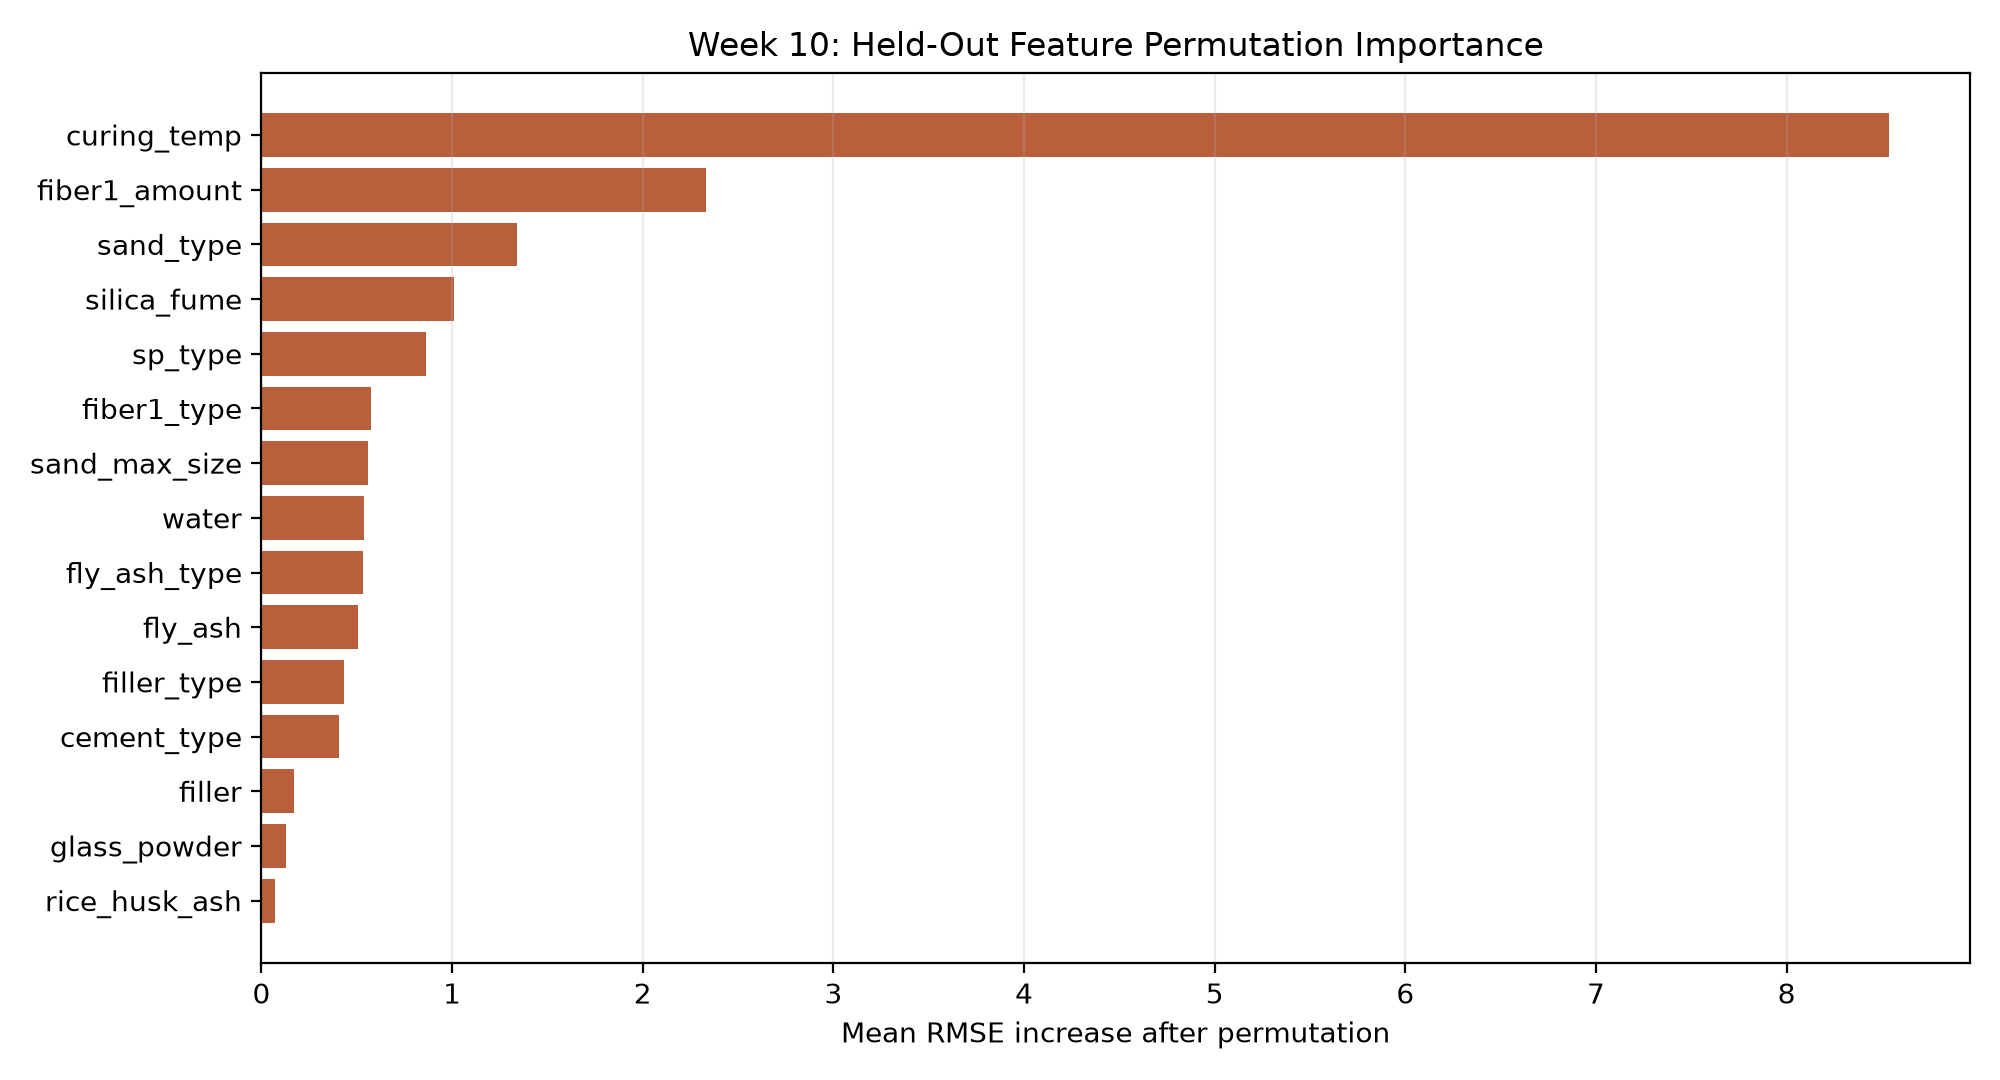

In [11]:
display(Image(filename=str(FIGURE_DIR / 'week10_feature_permutation_importance.png')))

### Feature-Level Permutation Interpretation

The permutation ranking confirms the main individual-feature story: **curing temperature** is the most important individual feature by a large margin. When curing temperature is permuted, RMSE increases by about 8.5 MPa, which is roughly a 30 percent increase over the baseline test RMSE.

The next most important features are **fibre amount**, **sand type**, **silica fume**, and **superplasticizer type**. This supports the idea that both processing conditions and mix-design features are important for generalization to unseen publications.

In [12]:
group_perm_cols = [
    'permutation_rank',
    'feature_group',
    'baseline_rmse',
    'mean_permuted_rmse',
    'mean_rmse_delta',
    'std_rmse_delta',
    'mean_rmse_delta_percentage',
    'n_features_permuted',
]
group_permutation_display = group_permutation[group_perm_cols].copy()
group_permutation_display['feature_group'] = group_permutation_display['feature_group'].map(GROUP_LABELS).fillna(group_permutation_display['feature_group'])
display(group_permutation_display)

,permutation_rank,feature_group,baseline_rmse,mean_permuted_rmse,mean_rmse_delta,std_rmse_delta,mean_rmse_delta_percentage,n_features_permuted
0,1,Curing,28.488,37.007,8.519,0.849,29.902,2
1,2,Fibres,28.488,32.326,3.838,0.507,13.473,6
2,3,Fillers and Aggregates,28.488,30.738,2.250,0.291,7.897,5
3,4,Binders and SCMs,28.488,29.350,0.862,0.430,3.024,17
4,5,Water,28.488,29.023,0.535,0.120,1.877,1
5,6,Chemical Admixtures,28.488,28.737,0.249,0.179,0.876,2


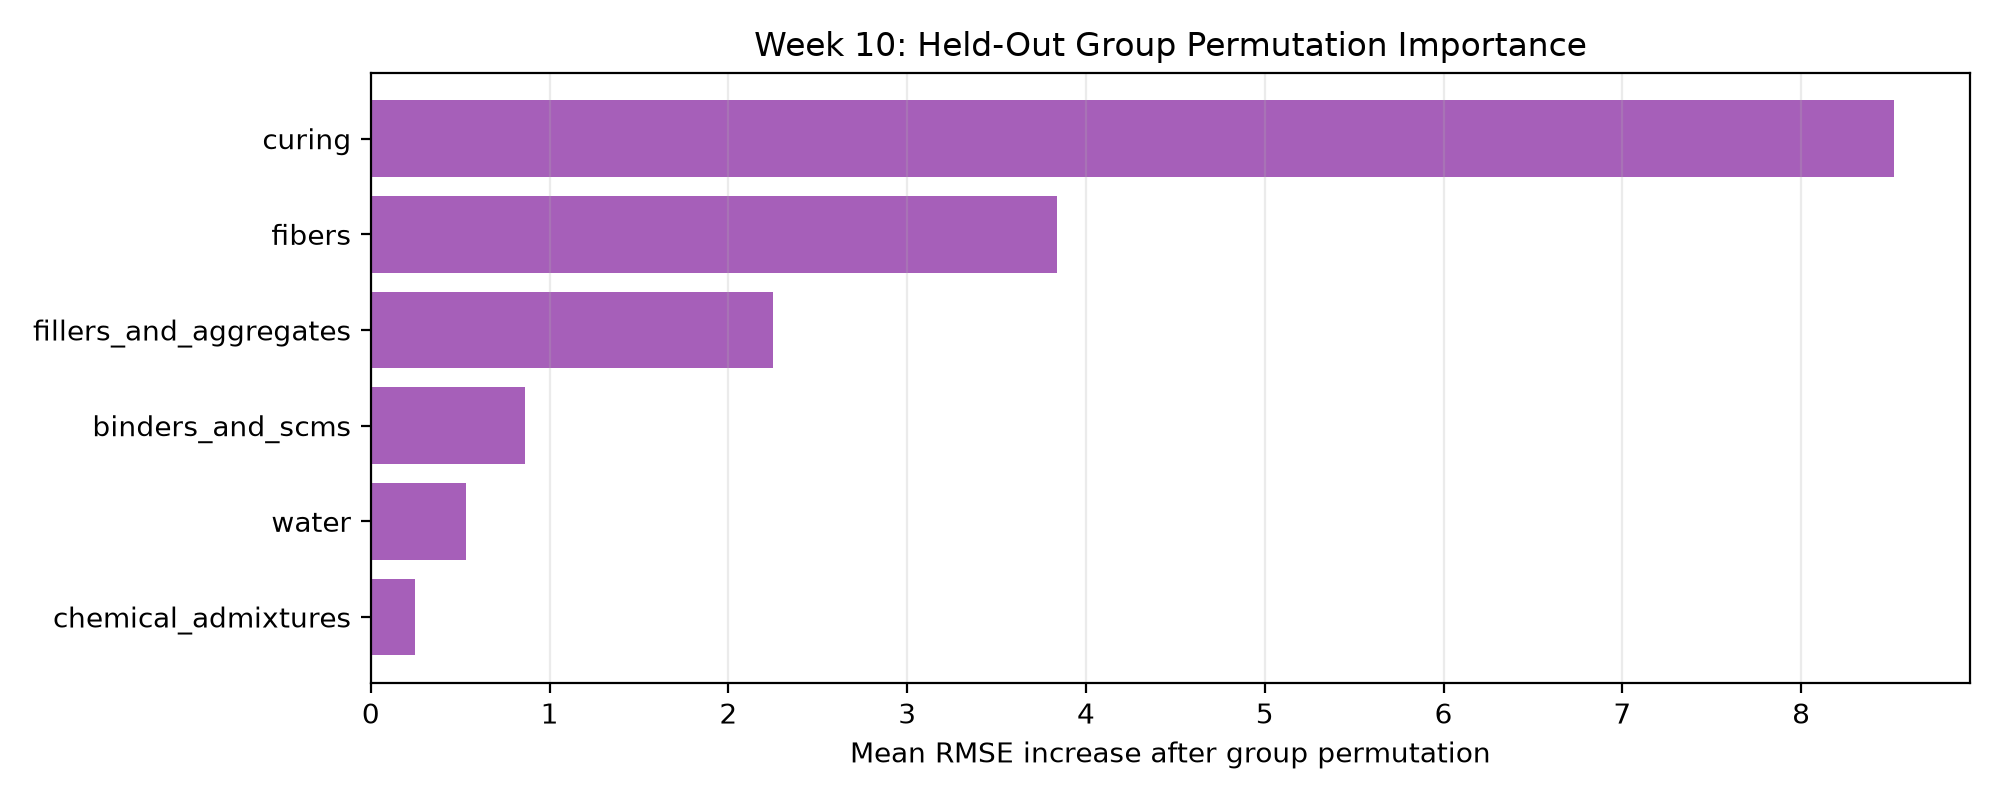

In [13]:
display(Image(filename=str(FIGURE_DIR / 'week10_group_permutation_importance.png')))

### Group-Level Permutation Interpretation

Group permutation ranks the groups as:

1. **Curing**
2. **Fibres**
3. **Fillers and aggregates**

This is useful for explaining the curing question. The grouped SHAP sum gives high total attribution to broad material groups, while permutation shows that curing is the most damaging group to shuffle. Curing may not be the largest SHAP-sum group, but it is highly important and very strong under permutation.

## 8. Agreement Between Attribution and Permutation

The final reliability check compares SHAP-style attribution with permutation importance. For the group-level comparison, this section uses the teammate-style grouped SHAP sum so the presentation table is consistent with the updated report.


In [14]:
feature_row = agreement.loc[agreement['level'].eq('original_feature')].iloc[0]

shap_top3_groups = set(group_attribution_report.nsmallest(3, 'shap_sum_rank')['feature_group'])
perm_top3_groups = set(group_attribution_report.nsmallest(3, 'permutation_rank')['feature_group'])
group_top3_overlap = len(shap_top3_groups & perm_top3_groups)
group_spearman = group_attribution_report['shap_sum_rank'].corr(
    group_attribution_report['permutation_rank'],
    method='spearman',
)

presentation_agreement = pd.DataFrame([
    {
        'level': 'original_feature',
        'n_entities': int(feature_row['n_entities']),
        'top_k': int(feature_row['top_k']),
        'top_k_overlap': int(feature_row['top_k_overlap']),
        'spearman_rank_correlation': feature_row['spearman_rank_correlation'],
        'reporting_convention': 'original feature SHAP rank',
    },
    {
        'level': 'feature_group',
        'n_entities': len(group_attribution_report),
        'top_k': 3,
        'top_k_overlap': group_top3_overlap,
        'spearman_rank_correlation': group_spearman,
        'reporting_convention': 'grouped SHAP sum',
    },
])

display(presentation_agreement)

,level,n_entities,top_k,top_k_overlap,spearman_rank_correlation,reporting_convention
0,original_feature,33,10,9,0.707,original feature SHAP rank
1,feature_group,6,3,2,0.543,grouped SHAP sum


In [15]:
rank_display = (
    group_attribution_report[[
        'feature_group_label',
        'shap_sum_rank',
        'permutation_rank',
        'shap_mean_teammate_style',
        'permutation_mean_rmse',
    ]]
    .sort_values('shap_sum_rank')
    .rename(columns={
        'feature_group_label': 'Feature Group',
        'shap_sum_rank': 'SHAP Sum Rank',
        'permutation_rank': 'Permutation Rank',
        'shap_mean_teammate_style': 'SHAP Mean',
        'permutation_mean_rmse': 'Permutation RMSE Increase',
    })
)

display(rank_display)

,Feature Group,SHAP Sum Rank,Permutation Rank,SHAP Mean,Permutation RMSE Increase
0,Binders and SCMs,1,4,21.495,0.862
1,Curing,2,1,13.852,8.519
2,Fillers and Aggregates,3,3,11.078,2.250
3,Fibres,4,2,10.085,3.838
4,Chemical Admixtures,5,6,3.801,0.249
5,Water,6,5,2.784,0.535


### Agreement Interpretation

At the original-feature level, 9 of the top 10 features overlap between SHAP attribution and permutation importance. The Spearman rank correlation is about 0.71, which indicates meaningful agreement but not perfect ranking identity.

At the group level, grouped SHAP sum and group permutation overlap on 2 of the top 3 groups. The difference is understandable: **Binders and SCMs** has many features and therefore a large total SHAP sum, while **Curing** creates the largest RMSE increase when shuffled. This is not a contradiction; it is a difference between contribution accounting and predictive-damage testing.


## 9. Main Conclusions

The interpretation gives the following conclusions for the fitted Elastic Net model:

1. **Curing temperature is the strongest individual feature.** It ranks first by both SHAP attribution and permutation importance.
2. **Curing is the most important group by predictive damage.** Shuffling curing variables increases held-out RMSE by about 8.5 MPa.
3. **Binders and SCMs have the largest grouped SHAP total.** This is expected because the group contains many cementitious and SCM variables.
4. **Fibres and fillers/aggregates remain important.** Fibre amount and sand type are both strong individual features.